# PEEC surface impedance: Dowell skin/proximity factors (companion demo)

Runnable companion to [`PEEC_SURFACE_IMPEDANCE.md`](PEEC_SURFACE_IMPEDANCE.md) (which keeps the full theory/derivation). This executes the **Dowell** skin-effect factors live: the resistance ratio `F(xi) = Re[ga coth ga]` (xi = half-thickness / skin depth) and the internal-inductance ratio `G(xi)`, the **coth (two-sided foil) vs tanh (one-sided slab / SIBC-ESIM)** boundary distinction, and a cross-check against radia's shipped `EMMaterial.dowell_Zs`.

*Complements `docs/peec_integration/peec_showcase.ipynb` (which shows the Dowell continued-fraction); here we focus on F/G vs thickness and the coth-vs-tanh comparison. Theory stays in the `.md`.*

## Live Dowell factors + radia cross-check

(1) F(xi): sinh/cosh form vs Re[ga coth ga] : max rel err = 2.66e-15
(2) radia EMMaterial.dowell_Zs Re vs analytic Re[ga tanh ga] : max rel err = 3.07e-14


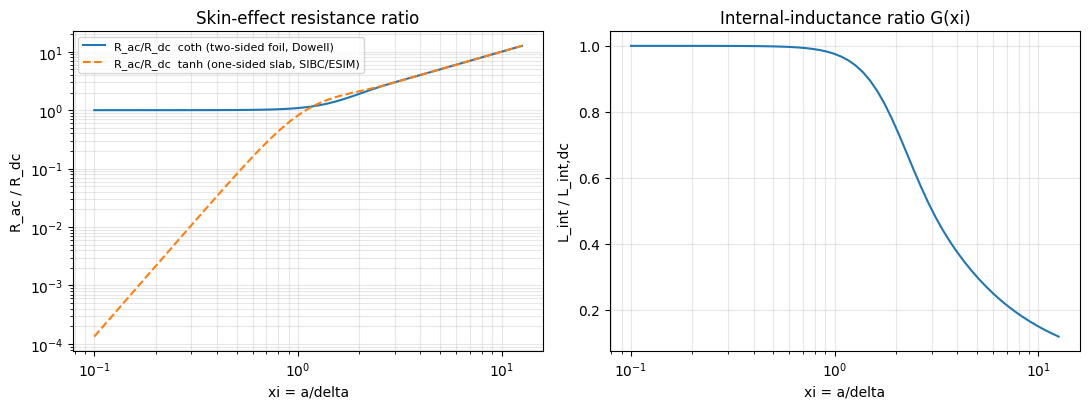

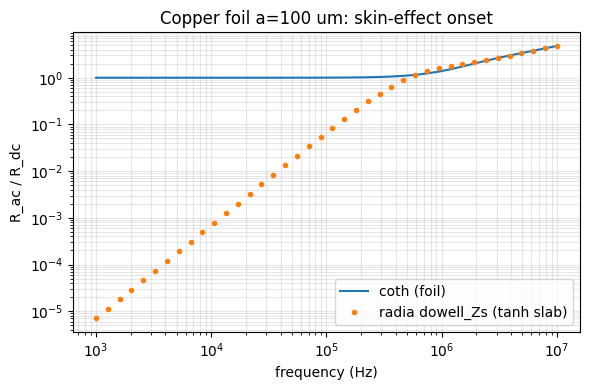


Copper: rho=1.724e-08 Ohm.m, delta(1 MHz)=66.1 um; at 1 MHz xi=1.51 -> R_ac/R_dc(coth)=1.39.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from radia.em_material import EMMaterial

# ---- analytic Dowell factors (doc: F(xi) = Re[ga coth ga], xi = a/delta) ----
def F_coth(xi):                       # two-sided foil (Dowell coth)
    return xi * (np.sinh(2*xi) + np.sin(2*xi)) / (np.cosh(2*xi) - np.cos(2*xi))
def F_coth_complex(xi):               # Re[ga coth ga] form
    ga = (1 + 1j) * xi
    return np.real(ga / np.tanh(ga))
def G_int(xi):                        # internal-inductance ratio L_int/L_int_dc (Dowell)
    return (3.0 / (2*xi)) * (np.sinh(2*xi) - np.sin(2*xi)) / (np.cosh(2*xi) - np.cos(2*xi))
def F_tanh(xi):                       # one-sided slab (ESIM/SIBC tanh) Re[ga tanh ga]
    ga = (1 + 1j) * xi
    return np.real(ga * np.tanh(ga))

xi = np.logspace(-1, 1.1, 60)
# (1) the two analytic forms of the coth factor agree
relerr = np.max(np.abs(F_coth(xi) - F_coth_complex(xi)) / F_coth(xi))
print(f"(1) F(xi): sinh/cosh form vs Re[ga coth ga] : max rel err = {relerr:.2e}")

# (2) radia's shipped Dowell surface impedance (tanh slab) cross-check
cu = EMMaterial.from_name("copper")
a = 100e-6                                  # 100 um copper foil half-thickness
freqs = np.logspace(3, 7, 40)               # 1 kHz .. 10 MHz
xi_f = np.array([a / cu.skin_depth(f) for f in freqs])
Zs = np.array([cu.dowell_Zs(f, a) for f in freqs])
R_dc = cu.rho / a
Rac_over_Rdc_radia = Zs.real / R_dc
relerr2 = np.max(np.abs(Rac_over_Rdc_radia - F_tanh(xi_f)) / F_tanh(xi_f))
print(f"(2) radia EMMaterial.dowell_Zs Re vs analytic Re[ga tanh ga] : max rel err = {relerr2:.2e}")

# ---- plots ----
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.2))
ax0.loglog(xi, F_coth(xi), label="R_ac/R_dc  coth (two-sided foil, Dowell)")
ax0.loglog(xi, F_tanh(xi), "--", label="R_ac/R_dc  tanh (one-sided slab, SIBC/ESIM)")
ax0.set_xlabel("xi = a/delta"); ax0.set_ylabel("R_ac / R_dc"); ax0.grid(alpha=0.3, which="both")
ax0.set_title("Skin-effect resistance ratio"); ax0.legend(fontsize=8)
ax1.semilogx(xi, G_int(xi))
ax1.set_xlabel("xi = a/delta"); ax1.set_ylabel("L_int / L_int,dc")
ax1.set_title("Internal-inductance ratio G(xi)"); ax1.grid(alpha=0.3, which="both")
plt.tight_layout(); display(fig); plt.close(fig)

# frequency view for the 100 um copper foil
fig2, ax = plt.subplots(figsize=(6, 4))
ax.loglog(freqs, F_coth(xi_f), label="coth (foil)")
ax.loglog(freqs, Rac_over_Rdc_radia, "o", ms=3, label="radia dowell_Zs (tanh slab)")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("R_ac / R_dc")
ax.set_title(f"Copper foil a={a*1e6:.0f} um: skin-effect onset"); ax.grid(alpha=0.3, which="both"); ax.legend()
plt.tight_layout(); display(fig2); plt.close(fig2)

print(f"\nCopper: rho={cu.rho:.3e} Ohm.m, delta(1 MHz)={cu.skin_depth(1e6)*1e6:.1f} um; "
      f"at 1 MHz xi={a/cu.skin_depth(1e6):.2f} -> R_ac/R_dc(coth)={F_coth(a/cu.skin_depth(1e6)):.2f}.")

**Takeaway:** `R_ac/R_dc` rises ~linearly with `xi` once `xi > 1` (current crowds into ~one skin depth); the **coth** (two-sided foil) and **tanh** (one-sided slab) forms agree at low `xi` and diverge by ~2x at high `xi` (the foil has two skin layers) -- the reason the SIBC/ESIM (tanh) boundary and the Dowell (coth) foil model must not be mixed. radia's `EMMaterial.dowell_Zs` (tanh) matches the analytic slab form to machine precision; for the PEEC continued-fraction / PRIMA ladder realisation see `radia.lanczos_reduction.expand_dowell_cf` and the peec_showcase notebook.